In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install statsmodels pmdarima

In [ ]:
!pip install arch

In [ ]:
import os
import warnings

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import yfinance as yf


import statsmodels.api as sm
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.forecasting.theta import ThetaModel
import pmdarima as pm
from arch import arch_model


from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

Processed data for ^GSPC (1356 weeks).
Processed data for ^NDX (1356 weeks).
Processed data for GC=F (1322 weeks).
Processed data for TLT (1222 weeks).
Processed data for BTC-USD (589 weeks).
Processed data for NGN=X (1152 weeks).
Processed data for ARS=X (1218 weeks).
Processed data for TRY=X (1095 weeks).
Processed data for BRL=X (1068 weeks).
Processed data for LKR=X (1149 weeks).
Processed data for GHS=X (964 weeks).
Processed data for HKD=X (1242 weeks).
Processed data for INR=X (1149 weeks).
Processed data for ZAR=X (1152 weeks).

Data preparation completed. Extracted 14 assets.

Saving individual asset data to Google Drive...
Successfully saved: /content/drive/MyDrive/R2DA/GSPC_log_data.csv
Successfully saved: /content/drive/MyDrive/R2DA/NDX_log_data.csv
Successfully saved: /content/drive/MyDrive/R2DA/GC_F_log_data.csv
Successfully saved: /content/drive/MyDrive/R2DA/TLT_log_data.csv
Successfully saved: /content/drive/MyDrive/R2DA/BTC-USD_log_data.csv
Successfully saved: /content

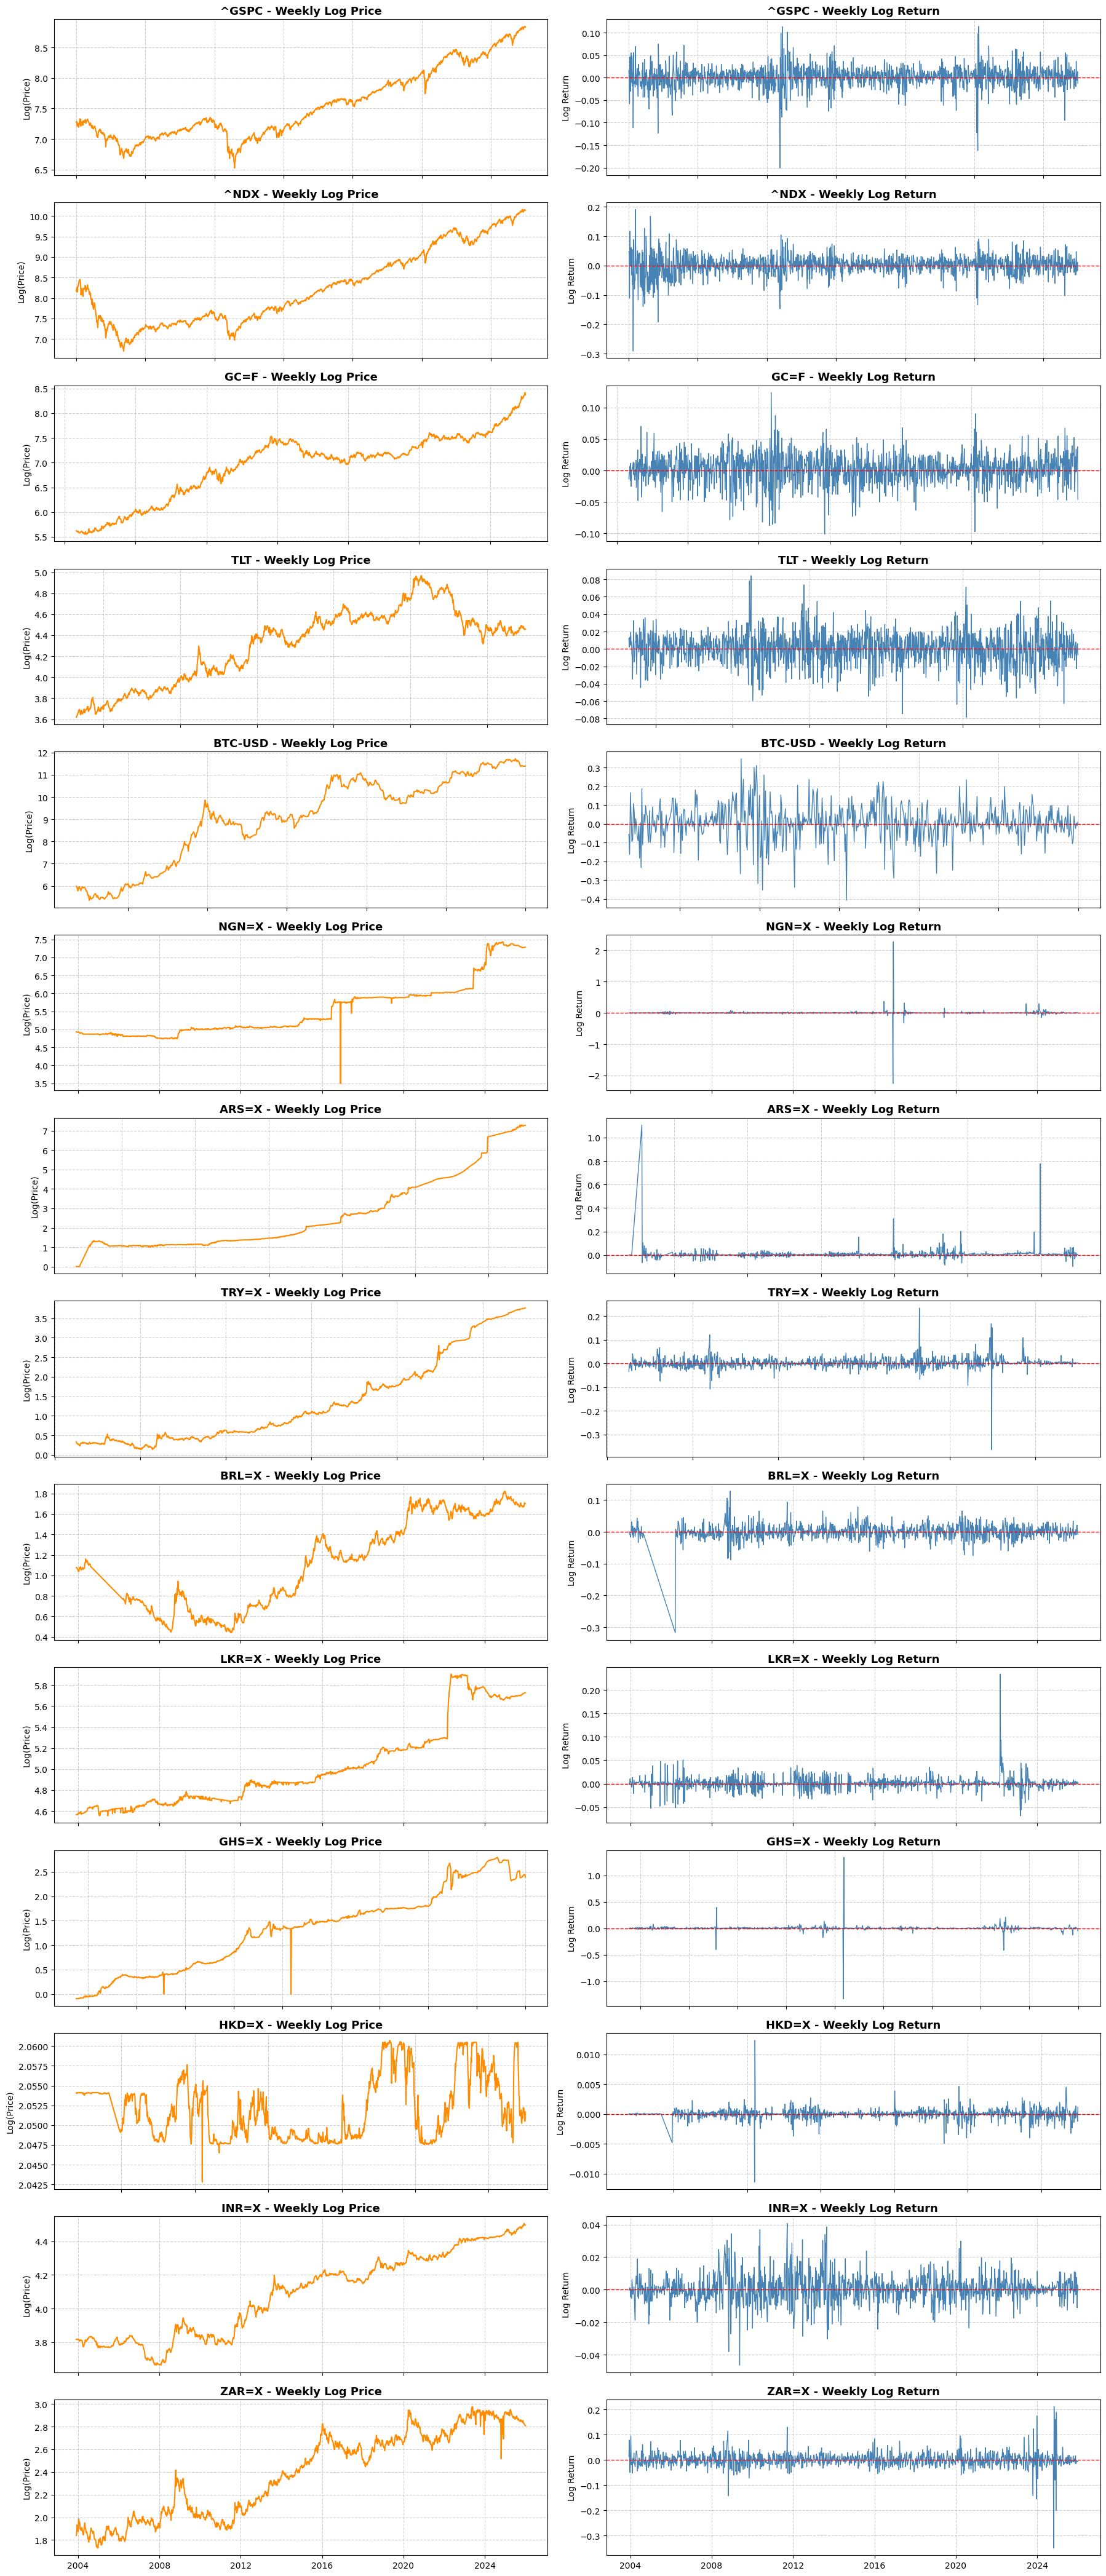

In [ ]:
# ==========================================
# 1. Download historical weekly data
# ==========================================
print("Downloading weekly historical data from Yahoo Finance and calculating returns...")

test_assets = [
    '^GSPC',
    '^NDX',
    'GC=F',
    'TLT',
    'BTC-USD',
    'NGN=X',
    'ARS=X',
    'TRY=X',
    'BRL=X',
    'LKR=X',
    'GHS=X',
    'HKD=X',
    'INR=X',
    'ZAR=X'
]

asset_data_dict = {}

for ticker in test_assets:
    try:
        # Download weekly data
        data = yf.download(ticker, start="2000-01-01", end="2026-01-01", interval="1wk", progress=False)

        if data.empty:
            print(f"Note: Data for {ticker} is empty. Skipping.")
            continue

        # Extract closing prices
        close = data['Close']

        # Handle yfinance version compatibility
        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]

        # Drop missing values
        weekly_price = close.dropna()
        if len(weekly_price) < 10:
            print(f"Note: Insufficient valid data for {ticker}. Skipping.")
            continue

        # Calculate weekly log price and log return
        log_price = np.log(weekly_price)
        log_ret = np.log(weekly_price / weekly_price.shift(1)).dropna()

        # Store in dictionary
        asset_data_dict[ticker] = {
            'log_price': log_price,
            'log_ret': log_ret
        }
        print(f"Processed data for {ticker} ({len(log_ret)} weeks).")

    except Exception as e:
        print(f"Error processing {ticker}: {e}")

print(f"\nData preparation completed. Extracted {len(asset_data_dict)} assets.")

# ==========================================
# 2. Save log price and log return to SEPARATE CSV files
# ==========================================
if len(asset_data_dict) > 0:
    print("\nSaving individual asset data to Google Drive...")

    # Define save path
    save_dir = '/content/drive/MyDrive/R2DA'
    os.makedirs(save_dir, exist_ok=True)

    for asset, data in asset_data_dict.items():
        # Create a dataframe for the individual asset
        asset_df = pd.DataFrame({
            'log_price': data['log_price'],
            'log_ret': data['log_ret']
        })

        # Clean the ticker string to make it a safe file name (e.g., ^GSPC -> GSPC, NGN=X -> NGN_X)
        safe_asset_name = asset.replace('^', '').replace('=', '_')

        # Define the exact file path for this asset
        csv_save_path = os.path.join(save_dir, f'{safe_asset_name}_log_data.csv')

        # Save to CSV
        asset_df.to_csv(csv_save_path)
        print(f"Successfully saved: {csv_save_path}")

# ==========================================
# 3. Plot Log Price and Log Return series
# ==========================================
n_assets = len(asset_data_dict)
if n_assets > 0:
    print(f"\nGenerating visualization charts for {n_assets} assets...")

    # Dynamically determine the number of rows for subplots
    fig, axes = plt.subplots(nrows=n_assets, ncols=2, figsize=(18, 3 * n_assets), dpi=100)

    # Convert axes to a 2D array if there is only one asset
    if n_assets == 1:
        axes = np.array([axes])

    # Iterate through the dictionary and plot
    for i, (asset, data) in enumerate(asset_data_dict.items()):

        ax_price = axes[i, 0]
        ax_ret = axes[i, 1]

        # ================= Plot Log Price =================
        ax_price.plot(data['log_price'].index, data['log_price'].values, linewidth=1.5, color='darkorange')
        ax_price.set_title(f'{asset} - Weekly Log Price', fontsize=13, fontweight='bold')
        ax_price.set_ylabel('Log(Price)', fontsize=10)
        ax_price.grid(True, linestyle='--', alpha=0.6)

        # ================= Plot Log Return =================
        ax_ret.plot(data['log_ret'].index, data['log_ret'].values, linewidth=1.0, color='steelblue')
        ax_ret.set_title(f'{asset} - Weekly Log Return', fontsize=13, fontweight='bold')
        ax_ret.set_ylabel('Log Return', fontsize=10)
        ax_ret.axhline(0, color='red', linewidth=1, linestyle='--')
        ax_ret.grid(True, linestyle='--', alpha=0.6)

    # Format x-axis date labels to prevent overlap
    fig.autofmt_xdate(bottom=0.2, rotation=0, ha='center', which='major')

    # Adjust layout spacing
    plt.tight_layout()

    # Show plot
    plt.show()
else:
    print("No data was successfully retrieved. Please check the network or ticker symbols.")

In [ ]:
# ==========================================
# 1. Parameter-Frozen Model Wrappers
# ==========================================

# --- Baseline 1: Zero Predictor ---
class ZeroWrapper(BaseEstimator, RegressorMixin):
    def fit(self, X, y): return self
    def predict(self, X_current, y_history):
        return 0.0

# --- Baseline 2: Rolling Historical Mean ---
class RollingMeanWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, window=8):
        self.window = window
    def fit(self, X, y): return self
    def predict(self, X_current, y_history):
        return np.mean(y_history[-self.window:])

# --- Traditional Time Series 1: Auto ARIMA ---
class AutoARIMAWrapper(BaseEstimator, RegressorMixin):
    def fit(self, X, y):
        self.model_ = pm.auto_arima(
            y, seasonal=False, stationary=True,
            stepwise=True, trace=False, error_action='ignore', suppress_warnings=True
        )
        self.last_t_ = len(y)
        return self
    def predict(self, X_current, y_history):
        if len(y_history) > self.last_t_:
            self.model_.update(y_history[-1:])
            self.last_t_ = len(y_history)
        return np.asarray(self.model_.predict(n_periods=1))[0]

# --- Traditional Time Series 2: AR(1)-GARCH(1,1) ---
class AR_GARCHWrapper(BaseEstimator, RegressorMixin):
    def fit(self, X, y):
        self.y_scaled = np.array(y) * 100.0
        self.model_ = arch_model(self.y_scaled, mean='AR', lags=1, vol='Garch', p=1, q=1)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            self.res_ = self.model_.fit(disp='off')
        return self
    def predict(self, X_current, y_history):
        current_y_scaled = np.array(y_history) * 100.0
        mod = arch_model(current_y_scaled, mean='AR', lags=1, vol='Garch', p=1, q=1)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            res_fixed = mod.fix(self.res_.params)
        forecasts = res_fixed.forecast(horizon=1, reindex=False)
        pred_scaled = forecasts.mean.iloc[-1, 0]
        return pred_scaled / 100.0

# --- Machine Learning 1: Ridge Regression ---
class RidgeWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, in_size=8): self.in_size = in_size
    def fit(self, X, y):
        X_seq, y_seq = [], []
        for i in range(len(y) - self.in_size):
            X_seq.append(y[i : i + self.in_size])
            y_seq.append(y[i + self.in_size])
        self.scaler_X = StandardScaler()
        X_seq_scaled = self.scaler_X.fit_transform(np.array(X_seq))
        self.model_ = Ridge(alpha=50.0)
        self.model_.fit(X_seq_scaled, np.array(y_seq))
        return self
    def predict(self, X_current, y_history):
        curr_input = y_history[-self.in_size:].reshape(1, -1)
        scaled_input = self.scaler_X.transform(curr_input)
        return self.model_.predict(scaled_input)[0]

# --- Machine Learning 2: Elastic Net ---
class ElasticNetWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, in_size=8): self.in_size = in_size
    def fit(self, X, y):
        X_seq, y_seq = [], []
        for i in range(len(y) - self.in_size):
            X_seq.append(y[i : i + self.in_size])
            y_seq.append(y[i + self.in_size])
        self.scaler_X = StandardScaler()
        X_seq_scaled = self.scaler_X.fit_transform(np.array(X_seq))
        self.model_ = ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42)
        self.model_.fit(X_seq_scaled, np.array(y_seq))
        return self
    def predict(self, X_current, y_history):
        curr_input = y_history[-self.in_size:].reshape(1, -1)
        scaled_input = self.scaler_X.transform(curr_input)
        return self.model_.predict(scaled_input)[0]

# --- Machine Learning 3: SVR ---
class SVRWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, in_size=8): self.in_size = in_size
    def fit(self, X, y):
        X_seq, y_seq = [], []
        for i in range(len(y) - self.in_size):
            X_seq.append(y[i : i + self.in_size])
            y_seq.append(y[i + self.in_size])
        self.scaler_X = StandardScaler()
        X_seq_scaled = self.scaler_X.fit_transform(np.array(X_seq))
        self.model_ = SVR(kernel='rbf', C=0.1, epsilon=0.01)
        self.model_.fit(X_seq_scaled, np.array(y_seq))
        return self
    def predict(self, X_current, y_history):
        curr_input = y_history[-self.in_size:].reshape(1, -1)
        scaled_input = self.scaler_X.transform(curr_input)
        return self.model_.predict(scaled_input)[0]

# --- Machine Learning 4: Random Forest ---
class RandomForestWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, in_size=8): self.in_size = in_size
    def fit(self, X, y):
        X_seq, y_seq = [], []
        for i in range(len(y) - self.in_size):
            X_seq.append(y[i : i + self.in_size])
            y_seq.append(y[i + self.in_size])
        self.model_ = RandomForestRegressor(
            n_estimators=100, max_depth=3, min_samples_leaf=10, random_state=42
        )
        self.model_.fit(np.array(X_seq), np.array(y_seq))
        return self
    def predict(self, X_current, y_history):
        curr_input = y_history[-self.in_size:].reshape(1, -1)
        return self.model_.predict(curr_input)[0]

# --- Machine Learning 5: XGBoost ---
class XGBoostWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, in_size=8): self.in_size = in_size
    def fit(self, X, y):
        X_seq, y_seq = [], []
        for i in range(len(y) - self.in_size):
            X_seq.append(y[i : i + self.in_size])
            y_seq.append(y[i + self.in_size])
        self.model_ = XGBRegressor(
            n_estimators=50, max_depth=2, learning_rate=0.05,
            reg_lambda=10.0, reg_alpha=5.0, random_state=42, n_jobs=-1
        )
        self.model_.fit(np.array(X_seq), np.array(y_seq))
        return self
    def predict(self, X_current, y_history):
        curr_input = y_history[-self.in_size:].reshape(1, -1)
        return self.model_.predict(curr_input)[0]

# --- Deep Learning 1: Finance MLP ---
class FinanceMLPWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, in_size=8): self.in_size = in_size
    def fit(self, X, y):
        X_seq, y_seq = [], []
        for i in range(len(y) - self.in_size):
            X_seq.append(y[i : i + self.in_size])
            y_seq.append(y[i + self.in_size])

        self.scaler_X = StandardScaler()
        self.scaler_y = StandardScaler()
        X_seq_scaled = self.scaler_X.fit_transform(np.array(X_seq))
        y_seq_scaled = self.scaler_y.fit_transform(np.array(y_seq).reshape(-1, 1)).flatten()

        self.model_ = MLPRegressor(
            hidden_layer_sizes=(4,), activation='tanh', solver='adam',
            alpha=0.1, max_iter=500, learning_rate_init=0.005,
            early_stopping=True, validation_fraction=0.15, random_state=42
        )
        self.model_.fit(X_seq_scaled, y_seq_scaled)
        return self
    def predict(self, X_current, y_history):
        curr_input = y_history[-self.in_size:].reshape(1, -1)
        scaled_input = self.scaler_X.transform(curr_input)
        pred_scaled = self.model_.predict(scaled_input)
        return self.scaler_y.inverse_transform(pred_scaled.reshape(-1, 1))[0, 0]

# --- Deep Learning 2: Finance RNN ---
class FinanceRNNWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, in_size=8): self.in_size = in_size
    def fit(self, X, y):
        X_seq, y_seq = [], []
        for i in range(len(y) - self.in_size):
            X_seq.append(y[i : i + self.in_size])
            y_seq.append(y[i + self.in_size])

        self.scaler_X = StandardScaler()
        self.scaler_y = StandardScaler()
        X_seq_scaled = self.scaler_X.fit_transform(np.array(X_seq)).reshape(-1, self.in_size, 1)
        y_seq_scaled = self.scaler_y.fit_transform(np.array(y_seq).reshape(-1, 1)).flatten()

        self.model_ = Sequential([
            SimpleRNN(4, input_shape=(self.in_size, 1), activation='tanh',
                      kernel_regularizer=regularizers.l2(0.05), recurrent_regularizer=regularizers.l2(0.05)),
            Dropout(0.2),
            Dense(1, activation='linear')
        ])
        self.model_.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=0.005))
        early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
        self.model_.fit(X_seq_scaled, y_seq_scaled, validation_split=0.15, epochs=150, batch_size=32, verbose=0, callbacks=[early_stop])
        return self
    def predict(self, X_current, y_history):
        curr_input = y_history[-self.in_size:].reshape(1, -1)
        scaled_input = self.scaler_X.transform(curr_input).reshape(1, self.in_size, 1)
        pred_scaled = self.model_.predict(scaled_input, verbose=0)
        return self.scaler_y.inverse_transform(pred_scaled.reshape(-1, 1))[0, 0]

In [ ]:
# ==========================================
# 2. Core Loop (Train Once, Predict Many)
# ==========================================
split_ratios = [0.8, 0.7, 0.6]
evaluation_results = []

for asset_name, data in asset_data_dict.items():
    print(f"\n" + "="*80)
    print(f"Processing asset: {asset_name}")

    # Extract pre-calculated weekly log returns
    y_full = data['log_ret'].values

    for split_ratio in split_ratios:
        train_pct = int(round(split_ratio * 100))
        test_pct = 100 - train_pct
        split_str = f"{train_pct}:{test_pct}"
        split_idx = int(len(y_full) * split_ratio)
        y_train_initial = y_full[:split_idx]
        y_test = y_full[split_idx:]
        N_test = len(y_test)

        if N_test < 10: continue

        # ----------------------------------------------------
        # Phase A: Train Once
        # ----------------------------------------------------
        print(f"[{asset_name} | Split {split_str}] Initializing and training models...")

        # Model Selection Panel: Toggle as needed
        model_names = [
            'Zero',
            'Mean',
            'AutoARIMA',
            'AR_GARCH',
            'Ridge',
            'ElasticNet',
            'SVR',
            'RF',
            'XGB',
            'MLP',
            'RNN'
        ]

        predictions = {name: [] for name in model_names}

        # Dynamically instantiate selected models
        models = {}
        if 'Zero' in model_names: models['Zero'] = ZeroWrapper()
        if 'Mean' in model_names: models['Mean'] = RollingMeanWrapper()
        if 'AutoARIMA' in model_names: models['AutoARIMA'] = AutoARIMAWrapper()
        if 'AR_GARCH' in model_names: models['AR_GARCH'] = AR_GARCHWrapper()
        if 'Ridge' in model_names: models['Ridge'] = RidgeWrapper()
        if 'ElasticNet' in model_names: models['ElasticNet'] = ElasticNetWrapper()
        if 'SVR' in model_names: models['SVR'] = SVRWrapper()
        if 'RF' in model_names: models['RF'] = RandomForestWrapper()
        if 'XGB' in model_names: models['XGB'] = XGBoostWrapper()
        if 'MLP' in model_names: models['MLP'] = FinanceMLPWrapper()
        if 'RNN' in model_names: models['RNN'] = FinanceRNNWrapper()

        # Perform a single fit operation for all selected models
        for name in model_names:
            models[name].fit(None, y_train_initial)

        # ----------------------------------------------------
        # Phase B: Rolling forward prediction on the test set
        # ----------------------------------------------------
        print(f"    - Starting rolling prediction (forward pass only, frozen parameters)...")

        for step, t in enumerate(range(split_idx, len(y_full))):
            if step > 0 and step % (max(1, N_test // 5)) == 0:
                print(f"    - Prediction progress: {int(step/N_test*100)}%")

            y_history = y_full[:t]

            for name in model_names:
                pred_val = models[name].predict(None, y_history)
                predictions[name].append(pred_val)

        print(f"    - Progress: 100% (Complete)")

        # ----------------------------------------------------
        # Phase C: Metric calculation and logging (Raw vs Trimmed)
        # ----------------------------------------------------
        train_returns_scaled = y_full[:split_idx] * 100
        full_returns_scaled = y_full * 100

        # Calculate GARCH volatility for Kappa scaling
        import warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            am_train = arch_model(train_returns_scaled, vol='Garch', p=1, q=1, mean='Zero')
            garch_train_res = am_train.fit(disp='off')
            am_full = arch_model(full_returns_scaled, vol='Garch', p=1, q=1, mean='Zero')
            garch_full_res = am_full.fix(garch_train_res.params)

        # Slice Numpy array directly
        cond_vol = garch_full_res.conditional_volatility[split_idx:] / 100
        z_t_test = y_test / cond_vol

        mse_naive_raw = np.mean(y_test**2)
        kappa_hat_raw = (np.mean(np.abs(z_t_test)))**2 / np.mean(z_t_test**2)

        # 2% Tail trimming
        trim_ratio = 0.02
        abs_y_test = np.abs(y_test)
        threshold = np.percentile(abs_y_test, 100 * (1 - trim_ratio))
        normal_mask = abs_y_test <= threshold

        y_test_trimmed = y_test[normal_mask]
        z_t_test_trimmed = z_t_test[normal_mask]
        mse_naive_trimmed = np.mean(y_test_trimmed**2)
        kappa_hat_trimmed = (np.mean(np.abs(z_t_test_trimmed)))**2 / np.mean(z_t_test_trimmed**2)

        for name in model_names:
            preds_arr = np.array(predictions[name])

            # --- Raw metrics ---
            r2_oos_raw = 1 - (np.mean((y_test - preds_arr)**2) / mse_naive_raw)
            actual_sign_raw = np.where(y_test >= 0, 1, -1)
            pred_sign_raw = np.where(preds_arr >= 0, 1, -1)
            da_raw = np.mean(actual_sign_raw == pred_sign_raw)
            x_val_raw = (2 * da_raw - 1)**2
            y_val_raw = r2_oos_raw / kappa_hat_raw

            # --- Trimmed metrics ---
            preds_trimmed = preds_arr[normal_mask]
            r2_oos_trimmed = 1 - (np.mean((y_test_trimmed - preds_trimmed)**2) / mse_naive_trimmed)
            actual_sign_trimmed = np.where(y_test_trimmed >= 0, 1, -1)
            pred_sign_trimmed = np.where(preds_trimmed >= 0, 1, -1)
            da_trimmed = np.mean(actual_sign_trimmed == pred_sign_trimmed)
            x_val_trimmed = (2 * da_trimmed - 1)**2
            y_val_trimmed = r2_oos_trimmed / kappa_hat_trimmed

            evaluation_results.append({
                'Asset': asset_name, 'Split': split_str, 'Model': name,
                'Raw_DA': da_raw, 'Raw_R2_OOS': r2_oos_raw, 'Raw_x': x_val_raw, 'Raw_y': y_val_raw,
                'Raw_Kappa': kappa_hat_raw,
                'DA': da_trimmed, 'R2_OOS': r2_oos_trimmed, 'x': x_val_trimmed, 'y': y_val_trimmed,
                'Trimmed_Kappa': kappa_hat_trimmed
            })


Processing asset: ^GSPC
[^GSPC | Split 80:20] Initializing and training models...
    - Starting rolling prediction (forward pass only, frozen parameters)...
    - Prediction progress: 19%
    - Prediction progress: 39%
    - Prediction progress: 59%
    - Prediction progress: 79%
    - Prediction progress: 99%
    - Progress: 100% (Complete)
[^GSPC | Split 70:30] Initializing and training models...
    - Starting rolling prediction (forward pass only, frozen parameters)...
    - Prediction progress: 19%
    - Prediction progress: 39%
    - Prediction progress: 59%
    - Prediction progress: 79%
    - Prediction progress: 99%
    - Progress: 100% (Complete)
[^GSPC | Split 60:40] Initializing and training models...
    - Starting rolling prediction (forward pass only, frozen parameters)...
    - Prediction progress: 19%
    - Prediction progress: 39%
    - Prediction progress: 59%
    - Prediction progress: 79%
    - Prediction progress: 99%
    - Progress: 100% (Complete)

Processing 

/tmp/ipykernel_830309/2927385926.py:41: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  self.res_ = self.model_.fit(disp='off')


    - Starting rolling prediction (forward pass only, frozen parameters)...
    - Prediction progress: 19%
    - Prediction progress: 39%
    - Prediction progress: 59%
    - Prediction progress: 79%
    - Prediction progress: 99%
    - Progress: 100% (Complete)
[NGN=X | Split 70:30] Initializing and training models...
    - Starting rolling prediction (forward pass only, frozen parameters)...
    - Prediction progress: 19%
    - Prediction progress: 39%
    - Prediction progress: 59%
    - Prediction progress: 79%
    - Prediction progress: 99%
    - Progress: 100% (Complete)
[NGN=X | Split 60:40] Initializing and training models...


/tmp/ipykernel_830309/2927385926.py:41: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  self.res_ = self.model_.fit(disp='off')


    - Starting rolling prediction (forward pass only, frozen parameters)...
    - Prediction progress: 19%
    - Prediction progress: 39%
    - Prediction progress: 59%
    - Prediction progress: 79%
    - Prediction progress: 99%
    - Progress: 100% (Complete)

Processing asset: ARS=X
[ARS=X | Split 80:20] Initializing and training models...
    - Starting rolling prediction (forward pass only, frozen parameters)...
    - Prediction progress: 19%
    - Prediction progress: 39%
    - Prediction progress: 59%
    - Prediction progress: 78%
    - Prediction progress: 98%
    - Progress: 100% (Complete)
[ARS=X | Split 70:30] Initializing and training models...
    - Starting rolling prediction (forward pass only, frozen parameters)...
    - Prediction progress: 19%
    - Prediction progress: 39%
    - Prediction progress: 59%
    - Prediction progress: 79%
    - Prediction progress: 99%
    - Progress: 100% (Complete)
[ARS=X | Split 60:40] Initializing and training models...
    - Starti


Plotting model evaluation scatter chart...
Scatter plot saved to: /content/drive/MyDrive/R2DA/model_evaluation_scatter.png


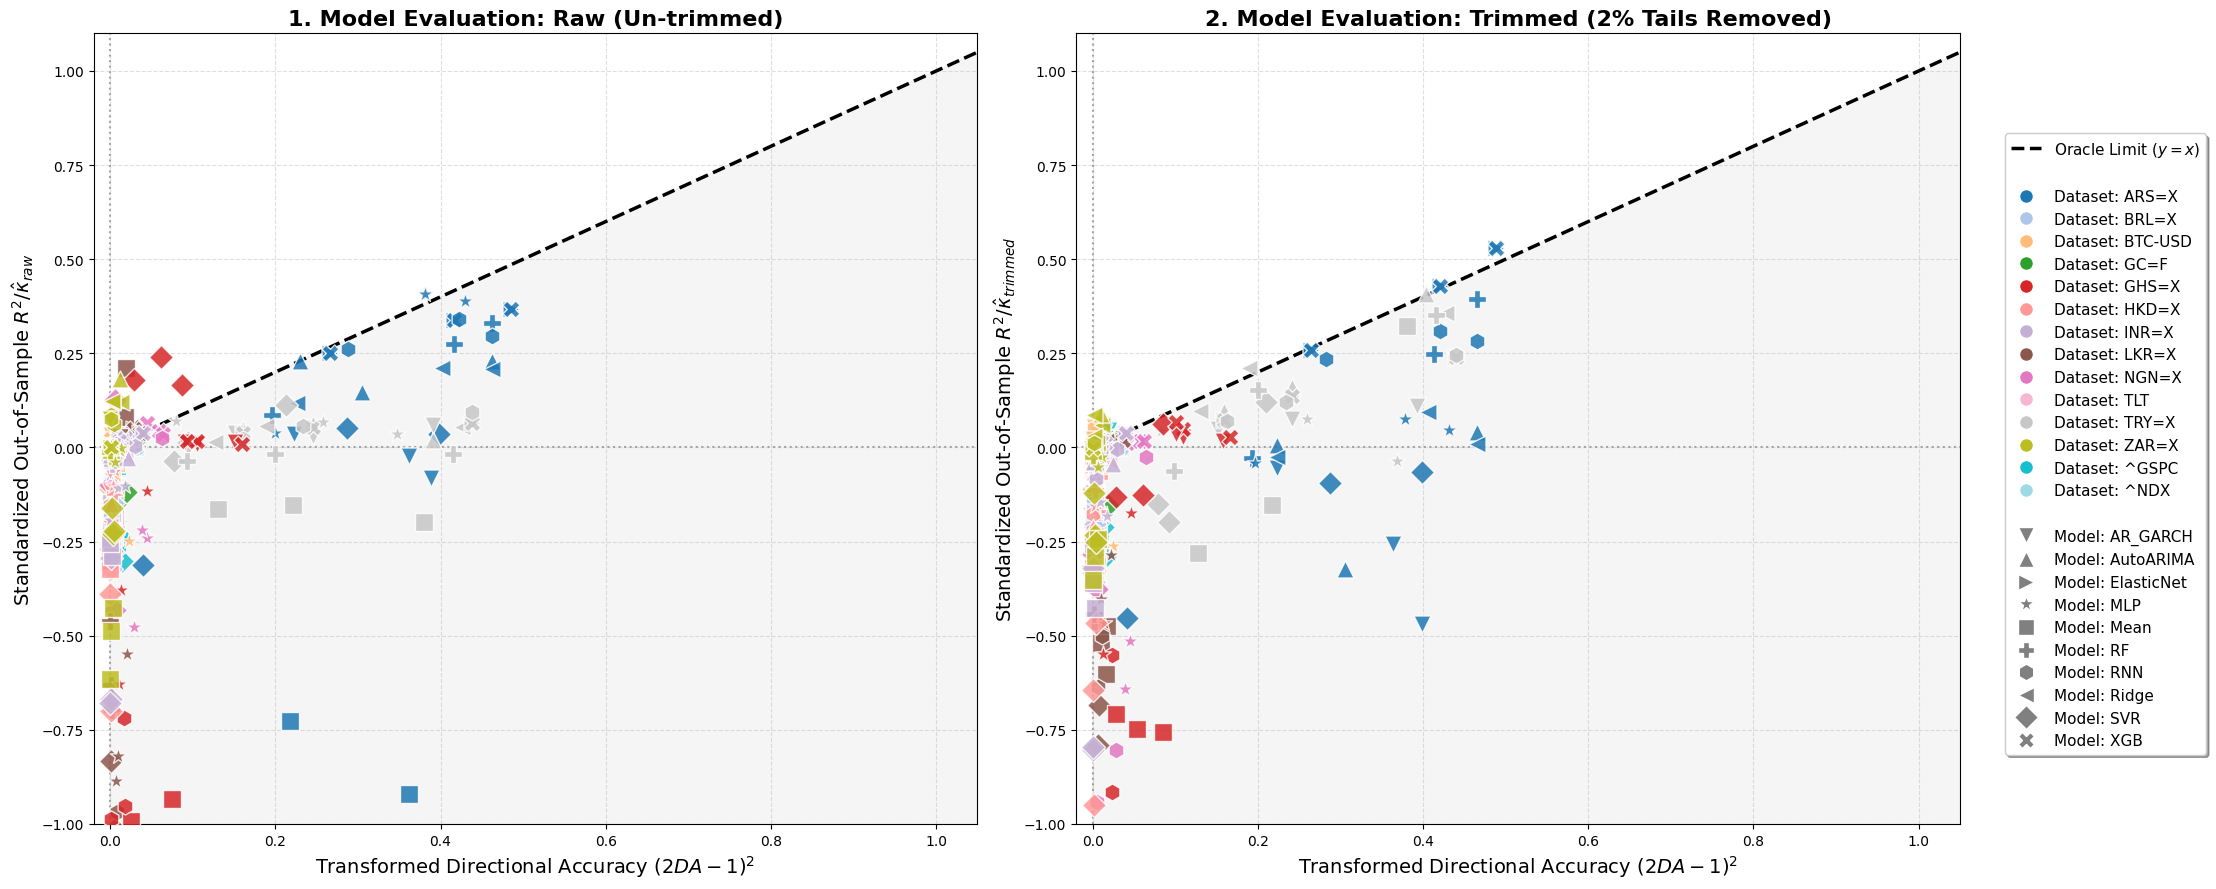


Model Evaluation Summary (Raw vs Trimmed including Kappa):
Raw results saved to: /content/drive/MyDrive/R2DA/model_evaluation_results.csv

  Asset Split      Model Raw_Kappa Raw_DA Raw_R2_OOS  Raw_x    Raw_y Trimmed_Kappa     DA  R2_OOS      x        y
  ARS=X 60:40   AR_GARCH    0.1209 0.7357     0.0042 0.2221   0.0347        0.4460 0.7364 -0.0246 0.2235  -0.0552
  ARS=X 60:40  AutoARIMA    0.1209 0.7398     0.0277 0.2299   0.2289        0.4460 0.7364  0.0031 0.2235   0.0069
  ARS=X 60:40 ElasticNet    0.1209 0.7582     0.0303 0.2667   0.2509        0.4460 0.7573  0.1156 0.2649   0.2592
  ARS=X 60:40        MLP    0.1209 0.7234     0.0045 0.1996   0.0374        0.4460 0.7218 -0.0189 0.1967  -0.0423
  ARS=X 60:40       Mean    0.1209 0.7336    -0.0879 0.2183  -0.7276        0.4460 0.7322 -0.7209 0.2157  -1.6165
  ARS=X 60:40         RF    0.1209 0.7213     0.0105 0.1959   0.0871        0.4460 0.7197 -0.0124 0.1930  -0.0279
  ARS=X 60:40        RNN    0.1209 0.7684     0.0317 0.2882   

In [ ]:
# ==========================================
# 3. Plot scatter chart (With Explicit Comment-Out Selection)
# ==========================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D

print("\nPlotting model evaluation scatter chart...")

# ---------------------------------------------------------
# CONFIGURATION PANEL: SELECTION & FILTERING
# (Simply comment out the lines you want to EXCLUDE)
# ---------------------------------------------------------
ACTIVE_ASSETS = [
     '^GSPC',
    '^NDX',
    'GC=F',
    'TLT',
    'BTC-USD',
    'NGN=X',
    'ARS=X',
    'TRY=X',
    'BRL=X',
    'LKR=X',
    'GHS=X',
    'HKD=X',
    'INR=X',
    'ZAR=X'
]

ACTIVE_MODELS = [
    # 'Zero',
    'Mean',
    'AutoARIMA',
    'AR_GARCH',
    'Ridge',
    'ElasticNet',
    'SVR',
    'RF',
    'XGB',
    'MLP',
    'RNN'
]
# ---------------------------------------------------------

ACTIVE_SPLITS = [
    # '90:10',
    # '85:15',
    '80:20',
    # '75:25',
    '70:30',
    # '65:35',
    '60:40'
]
# ---------------------------------------------------------

# Filter the results based on the active lists above
filtered_results = [
    res for res in evaluation_results
    if res['Asset'] in ACTIVE_ASSETS
    and res['Model'] in ACTIVE_MODELS
    and res['Split'] in ACTIVE_SPLITS
]

if not filtered_results:
    print("Warning: No data left! Please uncomment at least one asset, model, and split.")
else:
    # Extract all unique assets
    all_assets = sorted(list(set([res['Asset'] for res in filtered_results])))
    n_assets = len(all_assets)

    # Dynamically select colormap based on the number of assets
    if n_assets <= 10:
        asset_colors = cm.tab10(np.linspace(0, 1, n_assets))
    elif n_assets <= 20:
        asset_colors = cm.tab20(np.linspace(0, 1, n_assets))
    else:
        asset_colors = cm.turbo(np.linspace(0, 1, n_assets))

    asset_color_map = dict(zip(all_assets, asset_colors))

    # Updated marker map for the 11 Univariate Return Models
    model_marker_map = {
        'Zero': 'o',         # Circle
        'Mean': 's',         # Square
        'AutoARIMA': '^',    # Triangle Up
        'AR_GARCH': 'v',     # Triangle Down
        'Ridge': '<',        # Triangle Left
        'ElasticNet': '>',   # Triangle Right
        'SVR': 'D',          # Diamond
        'RF': 'P',           # Plus (filled)
        'XGB': 'X',          # X (filled)
        'MLP': '*',          # Star
        'RNN': 'h'           # Hexagon
    }

    run_models = sorted(list(set([res['Model'] for res in filtered_results])))

    fig, axes = plt.subplots(1, 2, figsize=(22, 9))
    data_list = filtered_results

    # --- Plot 1: Raw ---
    ax1 = axes[0]
    all_x_raw_plot = [res['Raw_x'] for res in data_list] + [res['Raw_y'] for res in data_list]
    max_raw_plot = max(all_x_raw_plot) if all_x_raw_plot else 1.0
    x_theory_raw = np.linspace(0, max(max_raw_plot, 1.0) + 0.1, 100)
    ax1.plot(x_theory_raw, x_theory_raw, 'k--', linewidth=2.5, zorder=3)
    ax1.fill_between(x_theory_raw, x_theory_raw, -1000, color='gray', alpha=0.08, zorder=1)

    for res in data_list:
        c = asset_color_map[res['Asset']]
        m = model_marker_map.get(res['Model'], 'p')
        ax1.scatter(res['Raw_x'], res['Raw_y'], s=150, color=c, marker=m, edgecolors='white', zorder=4, alpha=0.85)

    ax1.axhline(0, color='gray', linestyle=':', alpha=0.7, zorder=0)
    ax1.axvline(0, color='gray', linestyle=':', alpha=0.7, zorder=0)
    ax1.set_title("1. Model Evaluation: Raw (Un-trimmed)", fontsize=16, fontweight='bold')
    ax1.set_xlabel(r"Transformed Directional Accuracy $(2DA - 1)^2$", fontsize=14)
    ax1.set_ylabel(r"Standardized Out-of-Sample $R^2 / \hat{\kappa}_{raw}$", fontsize=14)
    ax1.grid(True, linestyle='--', alpha=0.4)

    all_y_raw = [res['Raw_y'] for res in data_list]
    ax1.set_xlim([-0.02, max(max_raw_plot, 1.0) + 0.05])
    # LIMITED Y-AXIS MINIMUM TO -1.0
    ax1.set_ylim([-1.0, max(max_raw_plot, 1.0) + 0.1 if all_y_raw else 1.0])

    # --- Plot 2: Trimmed ---
    ax2 = axes[1]
    all_x_trim_plot = [res['x'] for res in data_list] + [res['y'] for res in data_list]
    max_trim_plot = max(all_x_trim_plot) if all_x_trim_plot else 1.0
    x_theory_trim = np.linspace(0, max(max_trim_plot, 1.0) + 0.1, 100)
    line_handle, = ax2.plot(x_theory_trim, x_theory_trim, 'k--', linewidth=2.5, label=r'Oracle Limit ($y=x$)', zorder=3)
    ax2.fill_between(x_theory_trim, x_theory_trim, -1000, color='gray', alpha=0.08, zorder=1)

    for res in data_list:
        c = asset_color_map[res['Asset']]
        m = model_marker_map.get(res['Model'], 'p')
        ax2.scatter(res['x'], res['y'], s=150, color=c, marker=m, edgecolors='white', zorder=4, alpha=0.85)

    ax2.axhline(0, color='gray', linestyle=':', alpha=0.7, zorder=0)
    ax2.axvline(0, color='gray', linestyle=':', alpha=0.7, zorder=0)
    ax2.set_title("2. Model Evaluation: Trimmed (2% Tails Removed)", fontsize=16, fontweight='bold')
    ax2.set_xlabel(r"Transformed Directional Accuracy $(2DA - 1)^2$", fontsize=14)
    ax2.set_ylabel(r"Standardized Out-of-Sample $R^2 / \hat{\kappa}_{trimmed}$", fontsize=14)
    ax2.grid(True, linestyle='--', alpha=0.4)

    all_y_trim = [res['y'] for res in data_list]
    ax2.set_xlim([-0.02, max(max_trim_plot, 1.0) + 0.05])
    # LIMITED Y-AXIS MINIMUM TO -1.0
    ax2.set_ylim([-1.0, max(max_trim_plot, 1.0) + 0.1 if all_y_trim else 1.0])

    # Legends
    asset_legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=asset_color_map[a], markersize=10, label=a) for a in all_assets]
    model_legend_elements = [Line2D([0], [0], marker=model_marker_map.get(m, 'p'), color='w', markerfacecolor='gray', markersize=12, markeredgecolor='white', label=m) for m in run_models]
    blank_handle = Line2D([0], [0], color='w', alpha=0)
    all_legend_handles = [line_handle, blank_handle] + asset_legend_elements + [blank_handle] + model_legend_elements
    all_legend_labels = [r'Oracle Limit ($y=x$)', " "] + [f"Dataset: {a}" for a in all_assets] + [" "] + [f"Model: {m}" for m in run_models]

    fig.legend(all_legend_handles, all_legend_labels, loc='center left', bbox_to_anchor=(0.91, 0.5), fontsize=11, frameon=True, shadow=True)
    plt.tight_layout(rect=[0, 0, 0.9, 1])

    # Save plots
    save_dir = '/content/drive/MyDrive/R2DA'
    os.makedirs(save_dir, exist_ok=True)
    plot_save_path = os.path.join(save_dir, 'model_evaluation_scatter.png')
    fig.savefig(plot_save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Scatter plot saved to: {plot_save_path}")

    plt.show()

# ==========================================
# 4. Print and save results to CSV
# ==========================================
print("\n" + "="*130)
print("Model Evaluation Summary (Raw vs Trimmed including Kappa):")
print("="*130)

df_results = pd.DataFrame(filtered_results)

if not df_results.empty:
    # Save unformatted CSV (preserves full precision floats)
    csv_save_path = os.path.join(save_dir, 'model_evaluation_results.csv')
    df_results.to_csv(csv_save_path, index=False)
    print(f"Raw results saved to: {csv_save_path}\n")

    # Format columns for console printing
    format_cols = ['Raw_DA', 'Raw_R2_OOS', 'Raw_x', 'Raw_y', 'Raw_Kappa', 'DA', 'R2_OOS', 'x', 'y', 'Trimmed_Kappa']
    for col in format_cols:
        if col in df_results.columns:
            df_results[col] = df_results[col].apply(lambda val: f"{val:.4f}")

    # Reorder columns slightly to group Kappa nicely for reading
    display_cols = ['Asset', 'Split', 'Model', 'Raw_Kappa', 'Raw_DA', 'Raw_R2_OOS', 'Raw_x', 'Raw_y', 'Trimmed_Kappa', 'DA', 'R2_OOS', 'x', 'y']
    df_display = df_results[display_cols].sort_values(by=['Asset', 'Split', 'Model']).reset_index(drop=True)

    print(df_display.to_string(index=False))
else:
    print("No valid results found. Check if the models successfully generated predictions.")
print("="*130)

# ==========================================
# 5. Find maximum Y-axis (R2/Kappa) values and corresponding models
# ==========================================
if not df_results.empty:
    print("\n" + "="*80)
    print("Finding the model configuration with the maximum Y-axis value:")
    print("="*80)

    # Use numeric DataFrame to avoid argmax on formatted strings
    df_numeric = pd.DataFrame(filtered_results)

    # 1. Find the maximum value and its index for Raw_y (untrimmed)
    max_raw_y_idx = df_numeric['Raw_y'].idxmax()
    max_raw_y_row = df_numeric.loc[max_raw_y_idx]

    print("[Raw] Maximum Y-axis value:")
    print(f"    - Max value (Raw_y): {max_raw_y_row['Raw_y']:.6f}")
    print(f"    - Corresponding Raw_Kappa: {max_raw_y_row.get('Raw_Kappa', 'N/A'):.6f}")
    print(f"    - Asset: {max_raw_y_row['Asset']}")
    print(f"    - Split: {max_raw_y_row['Split']}")
    print(f"    - Model: {max_raw_y_row['Model']}")
    print("-" * 40)

    # 2. Find the maximum value and its index for Trimmed y (2% tails removed)
    max_trim_y_idx = df_numeric['y'].idxmax()
    max_trim_y_row = df_numeric.loc[max_trim_y_idx]

    print("[Trimmed] Maximum Y-axis value:")
    print(f"    - Max value (y): {max_trim_y_row['y']:.6f}")
    print(f"    - Corresponding Trimmed_Kappa: {max_trim_y_row.get('Trimmed_Kappa', 'N/A'):.6f}")
    print(f"    - Asset: {max_trim_y_row['Asset']}")
    print(f"    - Split: {max_trim_y_row['Split']}")
    print(f"    - Model: {max_trim_y_row['Model']}")
    print("="*80)

In [ ]:
# ==========================================
# 3. Data Summary and Statistics Table
# ==========================================
print("\nGenerating Data Summary and Statistics Table...")

summary_data = []

# Iterate over each asset in the dictionary
for asset_name, data in asset_data_dict.items():
    # Extract the log returns series
    log_ret_series = data['log_ret']
    y_full = log_ret_series.values

    # Skip assets with insufficient data
    if len(y_full) < 10:
        continue

    # Basic statistics
    start_date = log_ret_series.index.min().strftime('%Y-%m-%d')
    end_date = log_ret_series.index.max().strftime('%Y-%m-%d')
    n_obs = len(y_full)
    mean = np.mean(y_full)
    std_dev = np.std(y_full)
    skewness = stats.skew(y_full)
    kurtosis = stats.kurtosis(y_full) # Fisher's kurtosis (normal == 0)

    # Initialize dictionary to store data for this asset
    asset_summary = {
        'Asset': asset_name,
        'Start Date': start_date,
        'End Date': end_date,
        'N Obs': n_obs,
        'Mean': mean,
        'Std Dev': std_dev,
        'Skewness': skewness,
        'Kurtosis': kurtosis
    }

    # Calculate Kappa for each split ratio
    for split_ratio in split_ratios:
        split_idx = int(len(y_full) * split_ratio)
        y_test = y_full[split_idx:]

        if len(y_test) < 10:
            asset_summary[f'Kappa (Raw) {int(split_ratio*100)}%'] = np.nan
            asset_summary[f'Kappa (Trim) {int(split_ratio*100)}%'] = np.nan
            continue

        # Re-calculate GARCH volatility (same logic as main loop)
        train_returns_scaled = y_full[:split_idx] * 100
        full_returns_scaled = y_full * 100

        am_train = arch_model(train_returns_scaled, vol='Garch', p=1, q=1, mean='Zero')
        garch_train_res = am_train.fit(disp='off')
        am_full = arch_model(full_returns_scaled, vol='Garch', p=1, q=1, mean='Zero')

        # Suppress warnings from arch_model.fix() by catching output
        import warnings
        with warnings.catch_warnings():
             warnings.simplefilter("ignore")
             garch_full_res = am_full.fix(garch_train_res.params)

        cond_vol = garch_full_res.conditional_volatility[split_idx:] / 100
        z_t_test = y_test / cond_vol

        # Raw Kappa
        kappa_hat_raw = (np.mean(np.abs(z_t_test)))**2 / np.mean(z_t_test**2)

        # Trimmed Kappa (2%)
        trim_ratio = 0.02
        abs_y_test = np.abs(y_test)
        threshold = np.percentile(abs_y_test, 100 * (1 - trim_ratio))
        normal_mask = abs_y_test <= threshold

        z_t_test_trimmed = z_t_test[normal_mask]

        # Handle cases where trimming removes all data or variance becomes zero
        if len(z_t_test_trimmed) > 0 and np.mean(z_t_test_trimmed**2) > 0:
             kappa_hat_trimmed = (np.mean(np.abs(z_t_test_trimmed)))**2 / np.mean(z_t_test_trimmed**2)
        else:
             kappa_hat_trimmed = np.nan

        # Add to dictionary
        asset_summary[f'Kappa (Raw) {int(split_ratio*100)}%'] = kappa_hat_raw
        asset_summary[f'Kappa (Trim) {int(split_ratio*100)}%'] = kappa_hat_trimmed

    summary_data.append(asset_summary)

# Create full DataFrame
summary_df = pd.DataFrame(summary_data)

# ==========================================
# Split into Table 1 (Basic Stats) and Table 2 (Kappa)
# ==========================================
cols_basic = ['Asset', 'Start Date', 'End Date', 'N Obs', 'Mean', 'Std Dev', 'Skewness', 'Kurtosis']
kappa_cols_raw = [col for col in summary_df.columns if 'Kappa (Raw)' in col]
kappa_cols_trim = [col for col in summary_df.columns if 'Kappa (Trim)' in col]

# Interleave Raw and Trimmed Kappa columns for each split
kappa_cols = []
for r_col, t_col in zip(kappa_cols_raw, kappa_cols_trim):
    kappa_cols.extend([r_col, t_col])

# Create two separate DataFrames
df_basic = summary_df[cols_basic]
df_kappa = summary_df[['Asset'] + kappa_cols]

# Optional: Format the numerical columns for better display
format_dict_basic = {
    'Mean': '{:.6f}',
    'Std Dev': '{:.6f}',
    'Skewness': '{:.4f}',
    'Kurtosis': '{:.4f}'
}
format_dict_kappa = {col: '{:.4f}' for col in kappa_cols}

# Display the styled tables
try:
    from IPython.display import display
    display(df_basic.style.format(format_dict_basic).set_caption("Table 1: Data Summary and Basic Statistics"))
    display(df_kappa.style.format(format_dict_kappa).set_caption("Table 2: Kappa Statistics across Splits"))
except ImportError:
    print("\n--- Table 1: Data Summary and Basic Statistics ---")
    print(df_basic.to_string())
    print("\n--- Table 2: Kappa Statistics across Splits ---")
    print(df_kappa.to_string())

# Save to separate CSV files
save_dir = '/content/drive/MyDrive/R2DA'
os.makedirs(save_dir, exist_ok=True)

basic_csv_path = os.path.join(save_dir, 'data_summary_basic_stats.csv')
kappa_csv_path = os.path.join(save_dir, 'data_summary_kappa_stats.csv')

df_basic.to_csv(basic_csv_path, index=False)
df_kappa.to_csv(kappa_csv_path, index=False)

print(f"\nBasic stats table saved to: {basic_csv_path}")
print(f"Kappa stats table saved to: {kappa_csv_path}")


Generating Data Summary and Statistics Table...


,Asset,Start Date,End Date,N Obs,Mean,Std Dev,Skewness,Kurtosis
0,^GSPC,2000-01-08,2025-12-27,1356,0.001149,0.024819,-0.8726,7.0927
1,^NDX,2000-01-08,2025-12-27,1356,0.001451,0.034445,-0.7146,6.6168
2,GC=F,2000-09-04,2025-12-29,1322,0.002079,0.023565,-0.2908,1.8336
3,TLT,2002-08-05,2025-12-29,1222,0.000686,0.018868,-0.1596,1.3395
4,BTC-USD,2014-09-22,2025-12-29,589,0.009176,0.093840,-0.3472,1.9289
5,NGN=X,2003-12-08,2025-12-29,1152,0.002043,0.098612,0.2452,476.5001
6,ARS=X,2001-07-16,2025-12-29,1218,0.005978,0.044188,17.5678,393.1939
7,TRY=X,2005-01-10,2025-12-29,1095,0.003131,0.024664,-1.4312,55.4821
8,BRL=X,2003-12-08,2025-12-29,1068,0.000584,0.023694,-1.9568,31.7511
9,LKR=X,2003-12-08,2025-12-29,1149,0.001011,0.014235,3.8376,64.9548


,Asset,Kappa (Raw) 80%,Kappa (Trim) 80%,Kappa (Raw) 70%,Kappa (Trim) 70%,Kappa (Raw) 60%,Kappa (Trim) 60%
0,^GSPC,0.6051,0.6388,0.5690,0.6296,0.5629,0.6111
1,^NDX,0.6304,0.6642,0.5994,0.6498,0.5937,0.6431
2,GC=F,0.5944,0.6225,0.5728,0.5968,0.5859,0.6158
3,TLT,0.6271,0.6540,0.6017,0.6328,0.5968,0.6340
4,BTC-USD,0.5634,0.5918,0.4860,0.5464,0.5164,0.5693
5,NGN=X,0.1017,0.4140,0.1330,0.3125,0.1225,0.2525
6,ARS=X,0.0786,0.4805,0.0933,0.4910,0.1209,0.4460
7,TRY=X,0.3387,0.3701,0.4022,0.4398,0.4132,0.4996
8,BRL=X,0.6205,0.6545,0.6117,0.6456,0.6075,0.6406
9,LKR=X,0.0944,0.4206,0.1154,0.4600,0.1499,0.4564



Basic stats table saved to: /content/drive/MyDrive/R2DA/data_summary_basic_stats.csv
Kappa stats table saved to: /content/drive/MyDrive/R2DA/data_summary_kappa_stats.csv
